# Import Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)
from tensorflow.keras.utils import to_categorical

import matplotlib.pyplot as plt
import numpy as np

# Load MNIST Dataset

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape  :", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Data Shape : (60000, 28, 28)
Testing Data Shape  : (10000, 28, 28)


# Normalize the Data

In [3]:
X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

# Reshape for CNN

CNN expects:
(samples, height, width, channels)

In [4]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)

print("Reshaped Training Shape :", X_train.shape)
print("Reshaped Testing Shape  :", X_test.shape)

Reshaped Training Shape : (60000, 28, 28, 1)
Reshaped Testing Shape  : (10000, 28, 28, 1)


# One-Hot Encoding

In [5]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test, 10)

# Build CNN Model

In [6]:
model = Sequential([

    # --------------------------------
    # First Convolution Layer
    # --------------------------------
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),

    # Max Pooling
    MaxPooling2D(pool_size=(2,2)),

    # --------------------------------
    # Second Convolution Layer
    # --------------------------------
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu'
    ),

    # Max Pooling
    MaxPooling2D(pool_size=(2,2)),

    # --------------------------------
    # Flatten Layer
    # --------------------------------
    Flatten(),

    # --------------------------------
    # Fully Connected Layer
    # --------------------------------
    Dense(128, activation='relu'),

    # Dropout to reduce overfitting
    Dropout(0.5),

    # --------------------------------
    # Output Layer
    # --------------------------------
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Compile Model

In [7]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model Summary

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

# Train the Model

In [9]:
history = model.fit(
    X_train,
    y_train_cat,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 32ms/step - accuracy: 0.9330 - loss: 0.2202 - val_accuracy: 0.9818 - val_loss: 0.0627
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 80s 31ms/step - accuracy: 0.9747 - loss: 0.0852 - val_accuracy: 0.9856 - val_loss: 0.0482
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 33ms/step - accuracy: 0.9820 - loss: 0.0613 - val_accuracy: 0.9896 - val_loss: 0.0373
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 31ms/step - accuracy: 0.9852 - loss: 0.0494 - val_accuracy: 0.9898 - val_loss: 0.0325
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.9866 - loss: 0.0423 - val_accuracy: 0.9912 - val_loss: 0.0339
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 83s 28ms/step - accuracy: 0.9889 - loss: 0.0361 - val_accuracy: 0.9917 - val_loss: 0.0318
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.9901 - loss: 0.0308 - val_accuracy: 0.9905 - val_loss: 0.0328
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.9909 -

# Evaluate the Model

In [10]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat)

print("\nTest Loss     :", test_loss)
print("Test Accuracy :", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9927 - loss: 0.0261

Test Loss     : 0.026073263958096504
Test Accuracy : 0.9926999807357788


#  Plot Accuracy

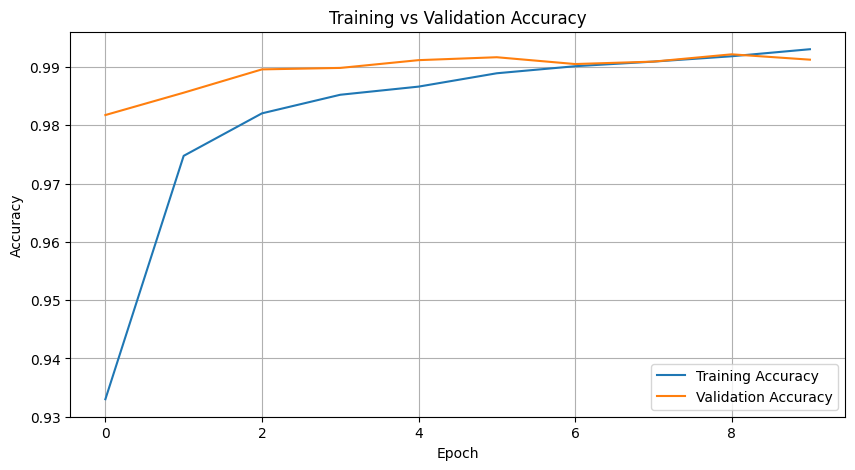

In [11]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

# Plot Loss

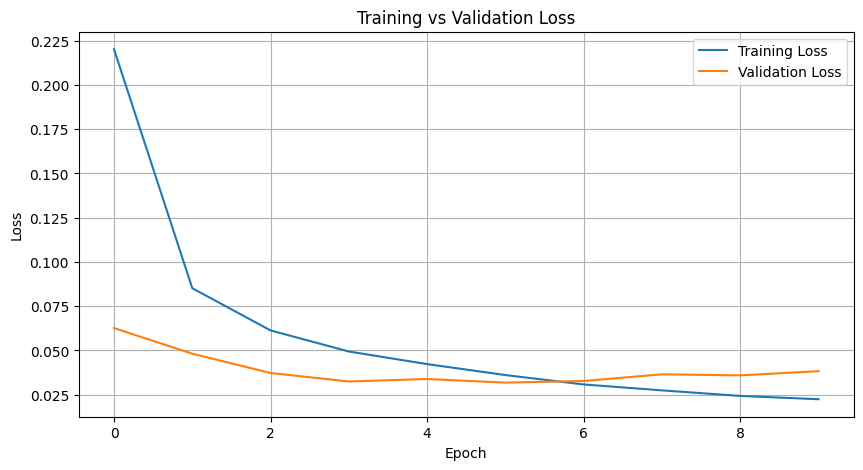

In [12]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

# Predictions

In [13]:
predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


# Visualize Predictions

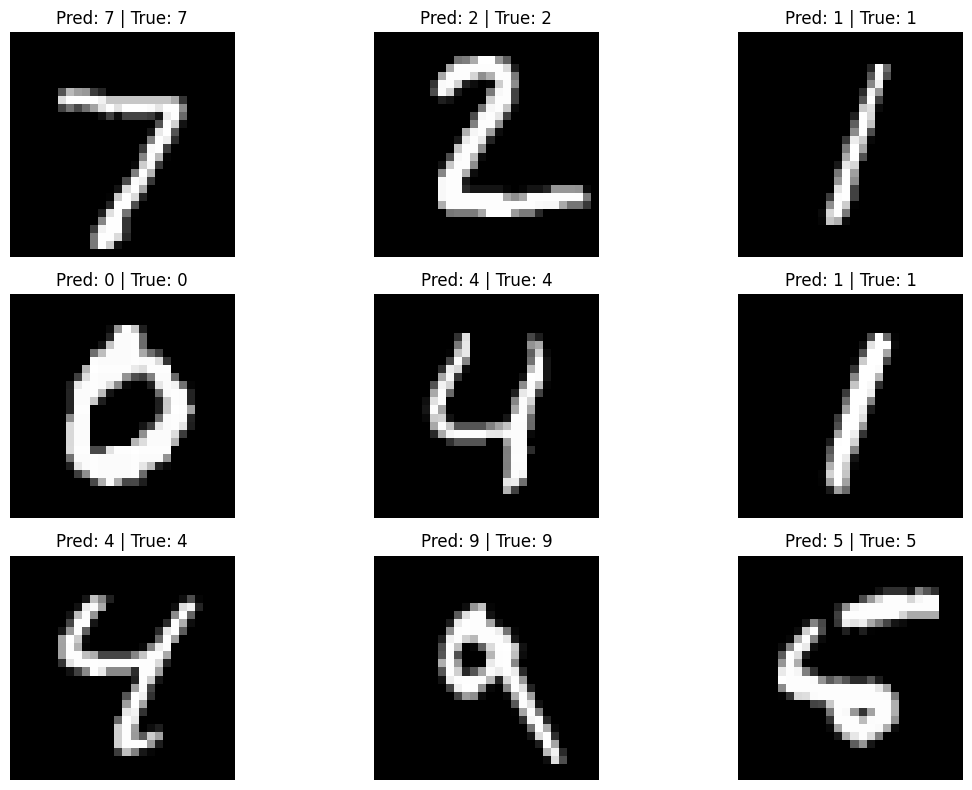

In [14]:
plt.figure(figsize=(12,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(X_test[i].reshape(28,28), cmap='gray')

    plt.title(
        f"Pred: {predicted_labels[i]} | True: {y_test[i]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

#  Hyperparameter Tuning

In [18]:

learning_rates = [0.01]
batch_sizes = [32, 64, 128]

results = []

for lr in learning_rates:

    for batch in batch_sizes:

        print(f"\nTraining with LR={lr}, Batch Size={batch}")

        model_tune = Sequential([

            Conv2D(
                32,
                (3,3),
                activation='relu',
                input_shape=(28,28,1)
            ),

            MaxPooling2D((2,2)),

            Conv2D(
                64,
                (3,3),
                activation='relu'
            ),

            MaxPooling2D((2,2)),

            Flatten(),

            Dense(128, activation='relu'),

            Dropout(0.5),

            Dense(10, activation='softmax')
        ])

        optimizer = tf.keras.optimizers.Adam(
            learning_rate=lr
        )

        model_tune.compile(
            optimizer=optimizer,
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        history_tune = model_tune.fit(
            X_train,
            y_train_cat,
            epochs=1,
            batch_size=batch,
            validation_split=0.2,
            verbose=0
        )

        loss, acc = model_tune.evaluate(
            X_test,
            y_test_cat,
            verbose=0
        )

        results.append({
            "Learning Rate": lr,
            "Batch Size": batch,
            "Test Accuracy": acc,
            "Test Loss": loss
        })


Training with LR=0.01, Batch Size=32


KeyboardInterrupt: 

# Print Results

In [ ]:
print("\nHyperparameter Tuning Results\n")

for result in results:
    print(result)

# Save the Model

In [ ]:
model.save("mnist_cnn_model.h5")

print("\nCNN Model Saved Successfully!")